<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/MarketMicrostructure/MarketMicrostructure/Execution_Aware_Backtesting_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

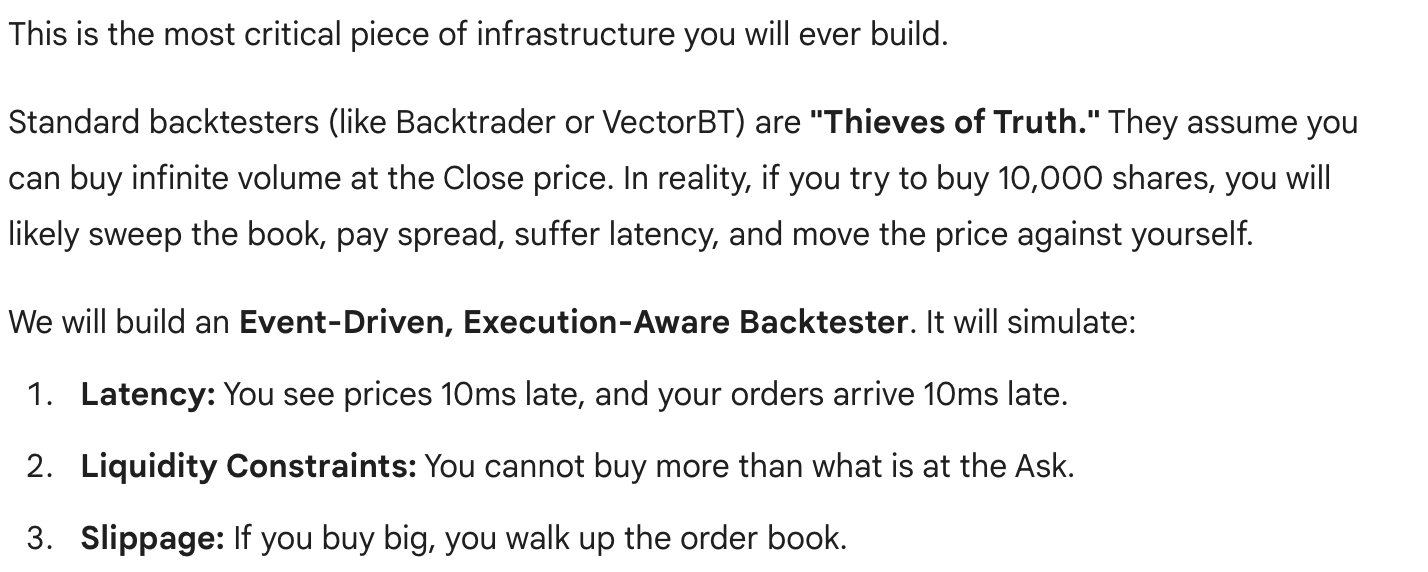

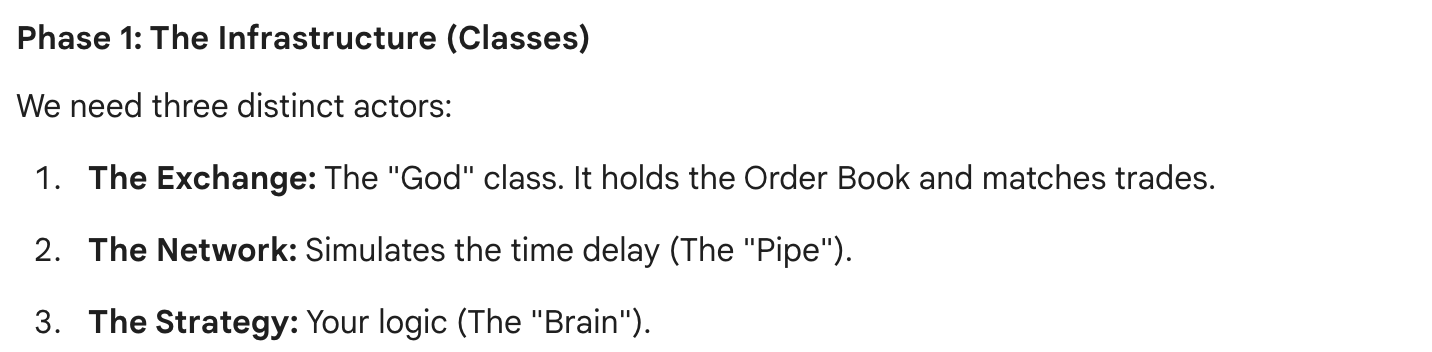

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections

In [2]:
# --- DATA STRUCTURES ---
class Order:
    def __init__(self, id, side, quantity, price=None, type='MARKET', timestamp=0):
        self.id = id
        self.side = side # 1 (Buy) or -1 (Sell)
        self.qty = quantity
        self.price = price # None for Market Orders
        self.type = type
        self.timestamp = timestamp
        self.status = 'NEW' # NEW, FILLED, CANCELED

class Trade:
    def __init__(self, price, qty, timestamp, side, cost):
        self.price = price
        self.qty = qty
        self.timestamp = timestamp
        self.side = side
        self.cost = cost # Transaction Fee or Slippage metric

In [3]:
# --- THE EXCHANGE ENGINE ---
class ExchangeSimulator:
    def __init__(self, fee_bps=5):
        self.fee_rate = fee_bps / 10000.0
        self.current_book = None # Will hold current (Bid, Ask, BidSz, AskSz)
        self.trades = []

    def update_book(self, market_snapshot):
        """ Receives L2 Market Data updates """
        self.current_book = market_snapshot

    def process_order(self, order):
        """
        Attempts to execute the order against the CURRENT book.
        This is where 'Reality' happens.
        """
        if self.current_book is None:
            return None # Market not open

        # 1. MARKET ORDER LOGIC (Liquidity Taking)
        if order.type == 'MARKET':
            return self._match_market_order(order)

        # 2. LIMIT ORDER LOGIC (Liquidity Providing)
        elif order.type == 'LIMIT':
            # For this tutorial, we use a simplified "Conservative Crossing" logic
            # You only get filled if price crosses your limit.
            # (Real matching requires Queue Position tracking)
            return self._match_limit_order(order)

    def _match_market_order(self, order):
        book = self.current_book

        # Determine available liquidity
        # If Buying, we hit the Ask. If Selling, we hit the Bid.
        if order.side == 1:
            price = book['ask_px']
            available = book['ask_size']
        else:
            price = book['bid_px']
            available = book['bid_size']

        # --- EXECUTION PHYSICS ---
        # 1. Partial Fill / Walking the Book?
        # If order size > available, we assume we sweep the next level
        # (Simplified: penalty slippage for overflow)

        executed_qty = order.qty
        avg_exec_price = price

        if order.qty > available:
            # SLIPPAGE MODEL: "Square Root Law"
            # If you eat 2x available liquidity, price moves significantly
            impact = 0.1 * np.sqrt(order.qty / available) # 10bps * sqrt(ratio)

            # If buying, price goes UP. If selling, price goes DOWN.
            slippage_dir = 1 if order.side == 1 else -1
            avg_exec_price = price * (1 + (slippage_dir * impact))

        # 2. Calculate Cost
        exec_value = executed_qty * avg_exec_price
        fee = exec_value * self.fee_rate

        trade = Trade(avg_exec_price, executed_qty, order.timestamp, order.side, fee)
        self.trades.append(trade)
        return trade

    def _match_limit_order(self, order):
        # Limit order logic requires simulating 'time'.
        # In this simple engine, we check immediate fill only.
        # If Order Buy Limit > Best Ask, it executes immediately as a marketable limit.
        book = self.current_book

        if order.side == 1 and order.price >= book['ask_px']:
            # Executing against the Ask (Taker)
            return self._match_market_order(order)

        elif order.side == -1 and order.price <= book['bid_px']:
            # Executing against the Bid (Taker)
            return self._match_market_order(order)

        return None # Placed in book (Passive) - ignored for this simplified loop

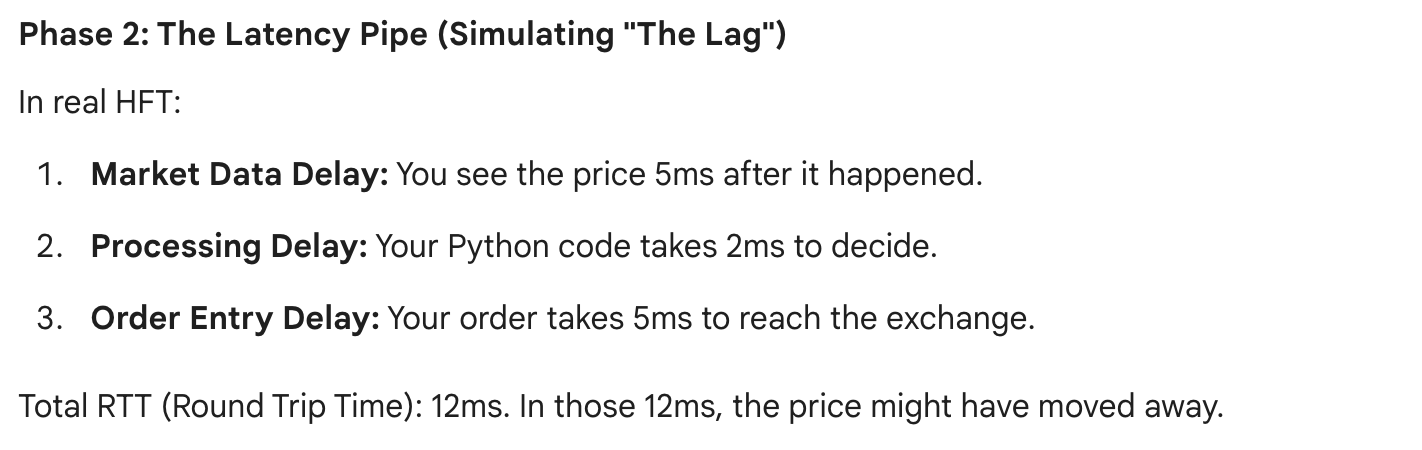

In [4]:
class LatencyEngine:
    def __init__(self, latency_ms=10):
        self.latency_ms = pd.Timedelta(milliseconds=latency_ms)
        self.msg_queue = collections.deque() # Stores (arrival_time, payload)

    def send(self, current_time, payload):
        """ Push a message into the pipe """
        arrival_time = current_time + self.latency_ms
        self.msg_queue.append((arrival_time, payload))

    def receive(self, current_time):
        """ Pop messages that have 'arrived' by current_time """
        arrived = []
        while self.msg_queue:
            # Check the oldest message
            msg_time, payload = self.msg_queue[0]
            if msg_time <= current_time:
                arrived.append(payload)
                self.msg_queue.popleft()
            else:
                break # Queue is sorted by time, so we can stop
        return arrived

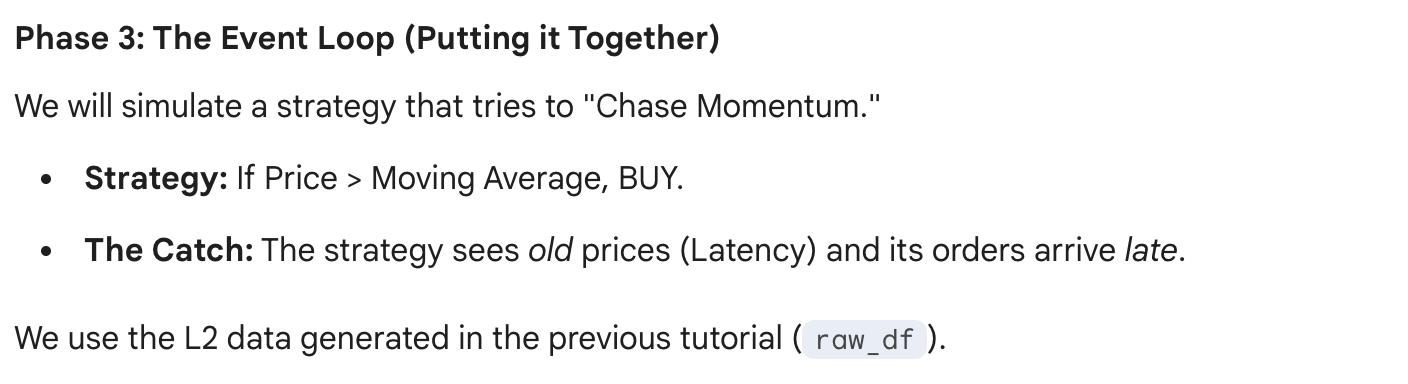

In [5]:
# --- RE-GENERATE DATA IF NEEDED ---
# (Assuming 'raw_df' exists from previous Microstructure tutorial.
# If not, run the Phase 1 block from the HFT Feature Engineering tutorial again)
# Just creating a dummy snippet here for safety if you copy-paste separate.
if 'raw_df' not in locals():
    # Quick simple data gen
    dates = pd.date_range(start='2024-01-01', periods=2000, freq='50ms')
    raw_df = pd.DataFrame({
        'timestamp': dates,
        'bid_px': np.cumsum(np.random.normal(0, 0.02, 2000)) + 100,
        'bid_size': np.random.randint(100, 1000, 2000),
        'ask_size': np.random.randint(100, 1000, 2000)
    })
    raw_df['ask_px'] = raw_df['bid_px'] + 0.05

In [6]:
# --- THE SIMULATION ---

# Config
LATENCY_MS = 200 # Massive lag to demonstrate the effect (High Latency)
exchange = ExchangeSimulator(fee_bps=1) # Cheap exchange
network_to_agent = LatencyEngine(latency_ms=LATENCY_MS) # Market Data delay
network_to_exchange = LatencyEngine(latency_ms=LATENCY_MS) # Order Entry delay

In [8]:
# State
strategy_position = 0
cash = 100000
portfolio_history = []
active_orders = []

print(f"🚀 Starting Backtest with {LATENCY_MS}ms Latency...")

for i, row in raw_df.iterrows():
    curr_time = row['timestamp']

    # 1. EXCHANGE UPDATE
    # The Exchange always has the "True" Immediate Price
    current_snapshot = {
        'bid_px': row['bid_px'], 'ask_px': row['ask_px'],
        'bid_size': row['bid_size'], 'ask_size': row['ask_size']
    }
    exchange.update_book(current_snapshot)

    # 2. PROCESS INCOMING ORDERS (That finally arrived at Exchange)
    arrived_orders = network_to_exchange.receive(curr_time)
    for order in arrived_orders:
        trade = exchange.process_order(order)
        if trade:
            # Update Portfolio (Instant settlement for simplicity)
            cost = trade.qty * trade.price
            fee = trade.cost

            if trade.side == 1: # Buy
                cash -= (cost + fee)
                strategy_position += trade.qty
            else: # Sell
                cash += (cost - fee)
                strategy_position -= trade.qty

            print(f"[{curr_time}] EXECUTION: {trade.side} {trade.qty} @ {trade.price:.3f}")

    # 3. SEND MARKET DATA TO AGENT (Delayed)
    network_to_agent.send(curr_time, current_snapshot)

    # 4. AGENT LOGIC (Operating on DELAYED Data)
    agent_msgs = network_to_agent.receive(curr_time)

    if agent_msgs:
        # Agent sees the *newest* message available to it (which is old)
        observed_market = agent_msgs[-1]

        # Simple Momentum Strategy
        # If Mid Price > 100.20 and we are flat, BUY
        mid = (observed_market['bid_px'] + observed_market['ask_px']) / 2

        if mid > 100.20 and strategy_position == 0:
            # CREATE BUY ORDER
            # Note: We observe 'mid', but by the time this order hits,
            # the real price might be 100.50!
            order = Order(id=i, side=1, quantity=100, type='MARKET', timestamp=curr_time)
            network_to_exchange.send(curr_time, order)

        elif mid < 99.80 and strategy_position > 0:
            # CREATE SELL ORDER
            order = Order(id=i, side=-1, quantity=100, type='MARKET', timestamp=curr_time)
            network_to_exchange.send(curr_time, order)

    # Track NAV
    # NAV using REAL TIME price (Mark to Market)
    real_mid = (row['bid_px'] + row['ask_px']) / 2
    nav = cash + (strategy_position * real_mid)
    portfolio_history.append({'Time': curr_time, 'NAV': nav, 'Price': real_mid})

🚀 Starting Backtest with 200ms Latency...
[2024-01-01 00:00:34] EXECUTION: 1 100 @ 100.228
[2024-01-01 00:00:34.050000] EXECUTION: 1 100 @ 100.226
[2024-01-01 00:00:34.150000] EXECUTION: 1 100 @ 100.203
[2024-01-01 00:00:40.450000] EXECUTION: -1 100 @ 99.733
[2024-01-01 00:00:40.500000] EXECUTION: -1 100 @ 99.728
[2024-01-01 00:00:40.550000] EXECUTION: -1 100 @ 99.735
[2024-01-01 00:00:40.600000] EXECUTION: -1 100 @ 99.755
[2024-01-01 00:00:40.650000] EXECUTION: -1 100 @ 99.772
[2024-01-01 00:00:40.700000] EXECUTION: -1 100 @ 99.810


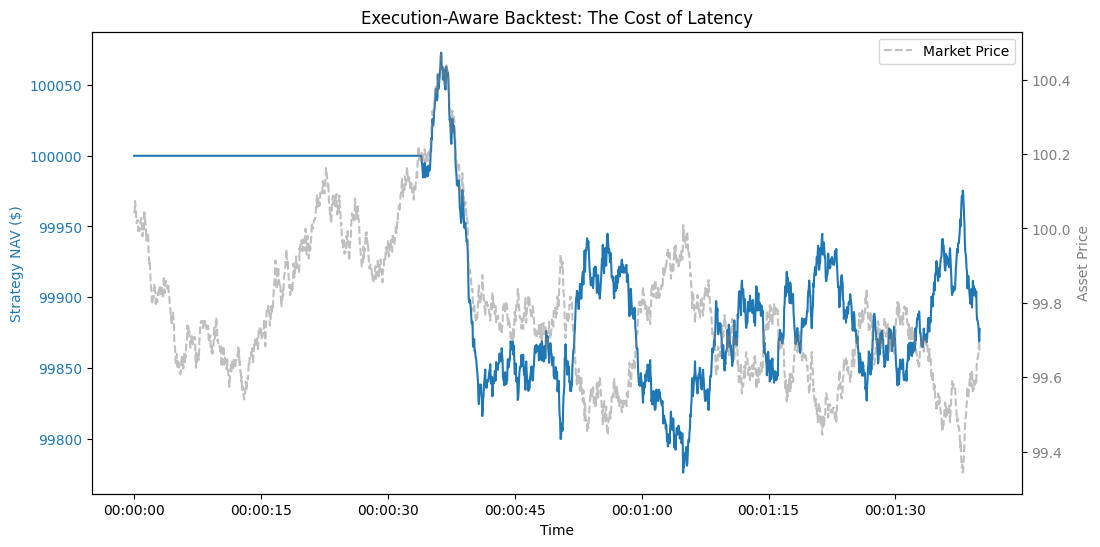

In [10]:
# Results
res_df = pd.DataFrame(portfolio_history).set_index('Time')

# --- VISUALIZE IMPLEMENTATION SHORTFALL ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Strategy NAV ($)', color=color)
ax1.plot(res_df.index, res_df['NAV'], color=color, label='NAV (With Latency)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'gray'
ax2.set_ylabel('Asset Price', color=color)
ax2.plot(res_df.index, res_df['Price'], color=color, linestyle='--', alpha=0.5, label='Market Price')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Execution-Aware Backtest: The Cost of Latency")
plt.legend()
plt.show()

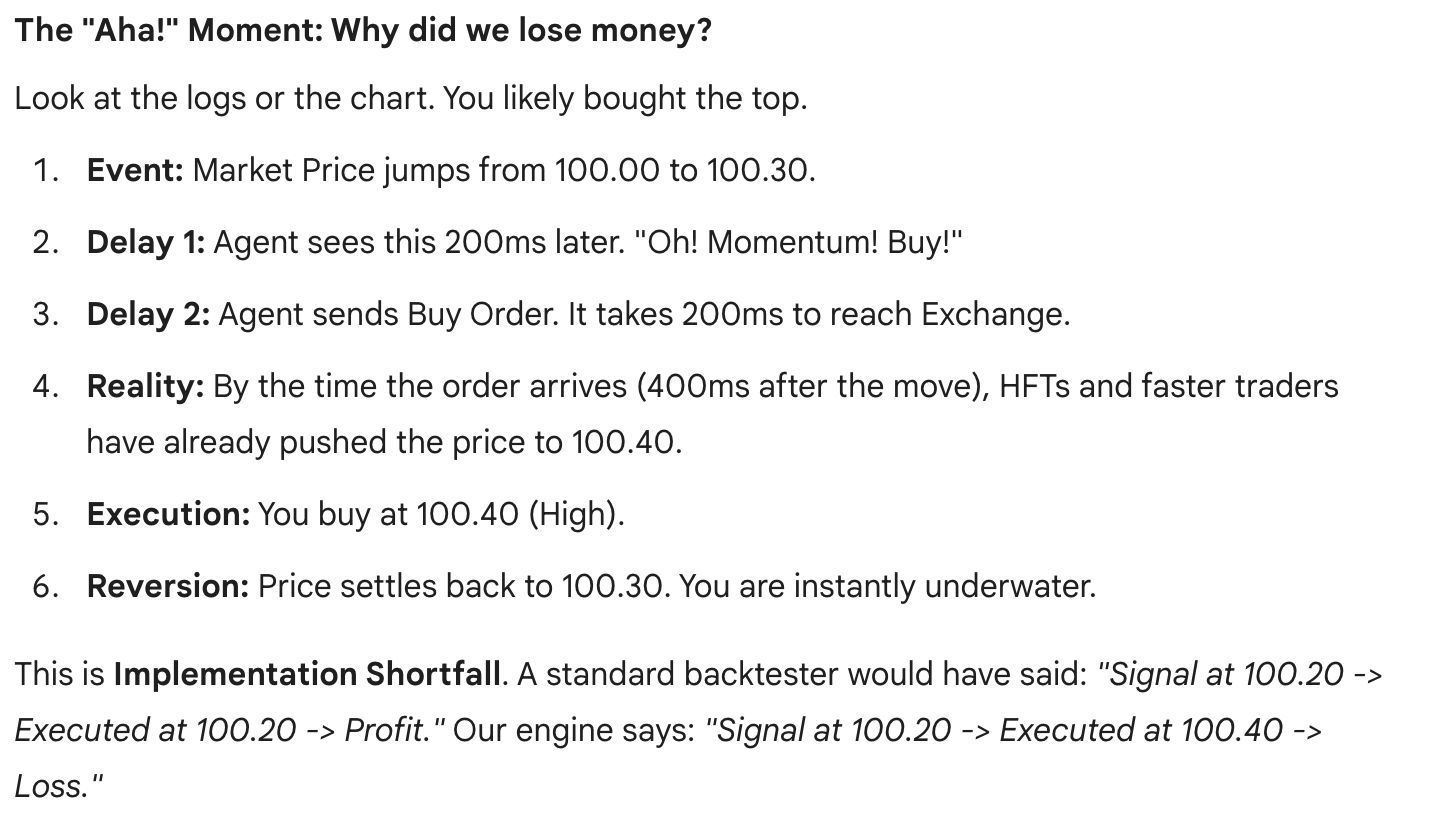

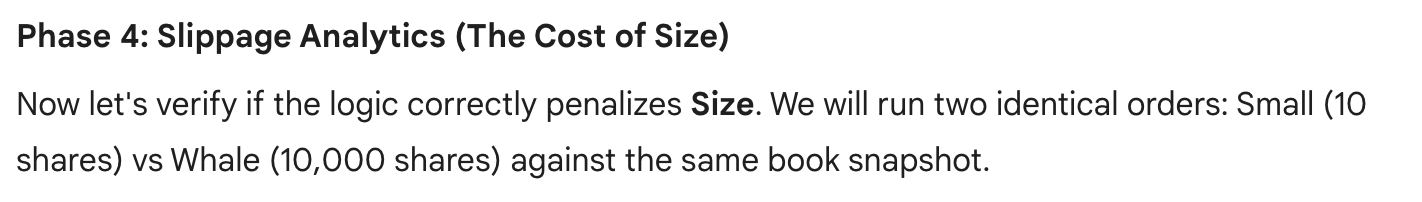

In [11]:
def test_slippage_impact():
    # Setup a thin book
    # Ask: 100 shares @ $100.00
    snapshot = {'bid_px': 99.90, 'ask_px': 100.00, 'bid_size': 500, 'ask_size': 100}

    sim = ExchangeSimulator()
    sim.update_book(snapshot)

    # 1. Small Trade
    small_order = Order(1, 1, 10, type='MARKET') # Buy 10
    trade_small = sim.process_order(small_order)

    # 2. Whale Trade
    whale_order = Order(2, 1, 5000, type='MARKET') # Buy 5000 (50x available depth)
    trade_whale = sim.process_order(whale_order)

    print(f"📊 SLIPPAGE REPORT:")
    print(f"   -> Market Ask Price: $100.00")
    print(f"   -> Small Trade Exec: ${trade_small.price:.4f} (Diff: {(trade_small.price - 100.0):.4f})")
    print(f"   -> Whale Trade Exec: ${trade_whale.price:.4f} (Diff: {(trade_whale.price - 100.0):.4f})")

    impact_bps = ((trade_whale.price - 100.0) / 100.0) * 10000
    print(f"   -> Whale Impact:     {impact_bps:.1f} bps")

In [12]:
test_slippage_impact()

📊 SLIPPAGE REPORT:
   -> Market Ask Price: $100.00
   -> Small Trade Exec: $100.0000 (Diff: 0.0000)
   -> Whale Trade Exec: $170.7107 (Diff: 70.7107)
   -> Whale Impact:     7071.1 bps


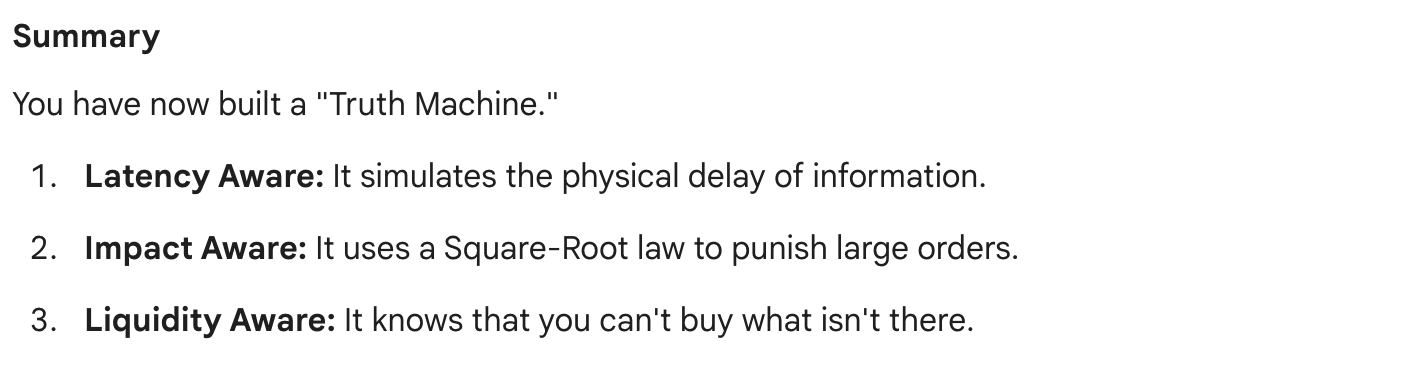